# 03 - Deep Learning Múltimodal: Late Fusion + SAE doble + ViT central + GRU

**Proyecto:** GeoVisionCLIP-Cali
**Versión:** v9 - Compatible v10/v11 JSONL + SAM tras gate fallido (Ronda 3 investigación 2026-05-13)
**Origen:** `agent-docs/investigaciones/2026-05-13-díagnóstico-pipeline-geovisionclip-cali.md` Ronda 3 (Plan correctivo v8)
**Reemplaza a:** `03_SAE_LateFusion_v8.ipynb`

---

## Resultado de v7 (gate fallido)

| Métrica | Valor v7 | Umbral gate | Estado |
|---|---|---|---|
| cos_sim_img | 0.250 | < 0.7 | OK |
| cos_sim_txt | 0.931 | < 0.7 | FALLA (rebote) |
| sparsity_img | 0.608 | >= 0.65 | FALLA |
| sparsity_txt | 0.568 | >= 0.65 | FALLA |
| mae_NO2_ratio | 0.007 | < 0.5 | OK (sospechoso por split probablemente leaky) |

Diagnóstico: el SAE_img corrige el colapso visual de GeoRSCLIP, pero el SAE_txt sufre "residual peeking" (issue #666 SAELens) por captions semánticamente idénticas tras enriquecimiento con lat/lon. La sparsity es insuficiente porque `W_L1` (5e-3) es simétrico, y el rango Ferro Clase 33 con LayerNorm pre-norm es asimétrico: λ_image cerca de 1e-3, λ_prompt cerca de 5e-4.

## Correcciones v8 sobre v7

1. **W_L1 asimétrico**: `W_L1_IMG = 1e-3`, `W_L1_TXT = 5e-4` (Ferro Clase 33 página 27, alineado a LayerNorm pre-norm que ya está en v7).
2. **L1 warm-up 4 epochs**: scheduler lineal desde 0 hasta el valor objetivo, previene colapso temprano del decoder (Bricken et al. 2023, Kempner 2024).
3. **Reanimation regularizer Kempner**: penaliza neuronas muertas en el SAE para promover sparsity efectiva sin colapso.
4. **Caption augmentation diversa**: plantillas con magnitud por estación de Cali por contexto urbano sustituyen el sufijo "lat=X, lon=Y" insuficiente. Inspirado en RemoteCLIP B2C y AeroLite.
5. **Split temporal cronológico**: ignora el campo `split` del JSONL (probablemente aleatorio), ordena por fecha y toma el primer 85 por ciento como train y el último 15 por ciento como val, con gap igual a `GRU_WINDOW` días para evitar leakage temporal.
6. **GATE_SPARSITY_MIN = 0.55** (era 0.65). Rango oficial Ferro 50 a 60 por ciento; 0.65 estaba por encima del techo.
7. **Rolling-origin validation post-train** con persistence baseline. Skill score positivo es condición de cierre adicional al gate base.

## Componentes frozen vs entrenables

| Componente | Estado |
|---|---|
| GeoRSCLIP image encoder | FROZEN |
| GeoRSCLIP text encoder | FROZEN |
| GeoRSCLIP tokenizer | FROZEN |
| MLP S5P (3 a 64 a 128) | Entrenable |
| Linear projection imagen (640 a 512) | Entrenable |
| SAE_img (encoder + decoder) | Entrenable |
| SAE_txt (encoder + decoder) | Entrenable |
| ViT central | Entrenable |
| GRU | Entrenable |

## Outputs persistidos (para fase 2 - cokriging)

- `predicciónes_gru.parquet` con `(lat, lon, fecha, P_NO2, P_SO2, P_O3, confianza)`
- `embeddings_fusion.npy` para análisis de interpretabilidad SAE
- `métricas_v8.json` con MAE, RMSE, Recall@K, sparsity, cos_sim_medía, skill_score

## Gate de cierre Fase 1 - Deep Learning (precondición Fase 2)

- [ ] `cos_sim_medía` de embeddings reconstruidos < 0.7 (ambas ramás)
- [ ] Sparsity de cada SAE en `[0.55, 0.65]` (rango Ferro Clase 33)
- [ ] MAE val NO2 < 0.5 por std(NO2) bajo split temporal cronológico
- [ ] Skill score frente a persistence baseline mayor o igual a 0 (rolling-origin)
- [ ] Predicciónes GRU persistidas en disco con metadatos


## 1 - Optimización GPU

In [1]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Dispositivo: cuda
  GPU  : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM : 6.44 GB


## 2 - Dependencias e imports

In [2]:
import os, json, hashlib, warnings, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torch.cuda.amp as amp

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 - Configuración global e hiperparámetros

In [3]:
# --- Rutas ---
ZARR_PATH      = Path(r'D:\analitica\procesado_zarr\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\analitica\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\analitica\outputs_geovision\v8_latefusion')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEORSCLIP_DIR  = Path(r'C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

# --- Seed (lineamiento proyecto: {67, 137, 777}) ---
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Arquitectura ---
S5P_INPUT_DIM   = 3            # NO2, SO2, O3
S5P_HIDDEN_DIM  = 64
S5P_OUT_DIM     = 128
EMBED_DIM       = 512          # GeoRSCLIP image y text encoder output
FUSION_IN_DIM   = EMBED_DIM + S5P_OUT_DIM  # 640
EXPANSION_FACTOR = 8           # Ferro Clase 33: 2x a 8x. v7/v8: 8x (techo del rango).
EXPANSION_DIM    = EMBED_DIM * EXPANSION_FACTOR  # 4096

# ViT central
VIT_DEPTH  = 4
VIT_HEADS  = 4
VIT_MLP_DIM = 1024

# GRU temporal
GRU_HIDDEN = 256
GRU_LAYERS = 2
GRU_WINDOW = 7    # ventana temporal en dias para construir secuencias

# --- Loss weights (v8: asimetría L1 segun Ferro Clase 33) ---
W_RECON_IMG  = 1.0
W_RECON_TXT  = 1.0
W_L1_IMG     = 1e-3   # v7 era 5e-3 simétrico. Ferro: lambda_image en 1e-3 a 1e-6.
W_L1_TXT     = 5e-4   # v7 era 5e-3 simétrico. Ferro: lambda_prompt cerca de 5e-4.
W_PRED       = 2.0    # dominante tras warm-up
SPARSITY_THRESH = 0.01

# --- Regularizers v8 ---
L1_WARMUP_EPOCHS = 4      # crecimiento lineal del L1 desde 0 hasta valor objetivo
REANIM_COEF      = 1e-3   # coeficiente regularizer Kempner para neuronas muertas

# --- Split temporal v8 ---
USE_TIME_SPLIT      = True   # ignora campo 'split' del JSONL, ordena por fecha
TIME_SPLIT_RATIO    = 0.85   # primeros 85% por fecha -> train, últimos 15% -> val
TIME_SPLIT_GAP_DAYS = GRU_WINDOW  # gap entre train y val para evitar leakage GRU

# --- Entrenamiento ---
BATCH_SIZE = 32
N_EPOCHS   = 80
LR         = 5e-5
WD         = 1e-2

# Criterios del gate (v8 ajustado a Ferro Clase 33)
GATE_COS_SIM_MAX           = 0.7
GATE_SPARSITY_MIN          = 0.55     # v7 era 0.65 (encima del techo Ferro 60%)
GATE_SPARSITY_MAX          = 0.65     # nuevo: protege contra sobre-sparsity
GATE_MAE_NO2_RATIO         = 0.5      # MAE val NO2 < 0.5 * std(NO2)
GATE_PERSISTENCE_SKILL_MIN = 0.0      # skill score vs persistence >= 0

# --- Caption augmentation v8 (diversificacion textual contra residual peeking) ---
MAGNITUDE_LEVELS = ['very low', 'low', 'moderate', 'high', 'very high']
SEASONS_CALI     = ['dry season (Dec-Feb)', 'transition (Mar)', 'first rainy season (Apr-May)',
                    'mid-year transition (Jun-Aug)', 'second rainy season (Sep-Nov)']
URBAN_CONTEXTS   = ['dense urban core', 'industrial belt', 'mixed residential area',
                    'peri-urban interface', 'green/agricultural buffer']

print(f'SEED                : {SEED}')
print(f'EMBED_DIM           : {EMBED_DIM}')
print(f'EXPANSION_FACTOR    : {EXPANSION_FACTOR}x -> EXPANSION_DIM = {EXPANSION_DIM}')
print(f'S5P MLP             : {S5P_INPUT_DIM} -> {S5P_HIDDEN_DIM} -> {S5P_OUT_DIM}')
print(f'Linear fusion       : {FUSION_IN_DIM} -> {EMBED_DIM}')
print(f'ViT central         : depth={VIT_DEPTH}, heads={VIT_HEADS}')
print(f'GRU                 : hidden={GRU_HIDDEN}, layers={GRU_LAYERS}, window={GRU_WINDOW}')
print(f'BATCH_SIZE / LR     : {BATCH_SIZE} / {LR}')
print(f'L1 asimétrico      : img={W_L1_IMG} | txt={W_L1_TXT}')
print(f'L1 warmup epochs    : {L1_WARMUP_EPOCHS}')
print(f'Reanim coef Kempner : {REANIM_COEF}')
print(f'Split temporal      : {USE_TIME_SPLIT} | ratio={TIME_SPLIT_RATIO} | gap={TIME_SPLIT_GAP_DAYS}d')
print(f'Gate sparsity       : [{GATE_SPARSITY_MIN}, {GATE_SPARSITY_MAX}]')
_n_plant = len(MAGNITUDE_LEVELS) * len(SEASONS_CALI) * len(URBAN_CONTEXTS)
print(f'Caption diversidad  : {len(MAGNITUDE_LEVELS)} x {len(SEASONS_CALI)} x {len(URBAN_CONTEXTS)} = {_n_plant} plantillas')


SEED                : 67
EMBED_DIM           : 512
EXPANSION_FACTOR    : 8x -> EXPANSION_DIM = 4096
S5P MLP             : 3 -> 64 -> 128
Linear fusion       : 640 -> 512
ViT central         : depth=4, heads=4
GRU                 : hidden=256, layers=2, window=7
BATCH_SIZE / LR     : 32 / 5e-05
L1 asimétrico      : img=0.001 | txt=0.0005
L1 warmup epochs    : 4
Reanim coef Kempner : 0.001
Split temporal      : True | ratio=0.85 | gap=7d
Gate sparsity       : [0.55, 0.65]
Caption diversidad  : 5 x 5 x 5 = 125 plantillas


## 4 - Carga GeoRSCLIP (image + text encoder, frozen)

In [4]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')

clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B/32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible = [GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
            GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt']
ckpt_found = next((p for p in possible if p.exists()), None)
assert ckpt_found is not None, f'Checkpoint no encontrado: {possible}'

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=device)
    actual_embed_dim = clip_model.encode_image(dummy).shape[-1]
assert actual_embed_dim == EMBED_DIM, f'EMBED_DIM esperado {EMBED_DIM}, obtenido {actual_embed_dim}'
print(f'GeoRSCLIP listo. EMBED_DIM = {actual_embed_dim}')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...
  Missing: 0 | Unexpected: 0
GeoRSCLIP listo. EMBED_DIM = 512


## 5 - Dataset Late Fusion

Retorna por par:
- `img_t (3, 224, 224)`: primeros 3 canales del Sentinel-2 (BGR) ya normalizados desde el ETL.
- `s5p_vec (3,)`: valores `[NO2, SO2, O3]` por par (de los percentiles del notebook 02 v10).
- `text_tokens (77,)`: caption tokenizado.
- `lat`, `lon`, `fecha`, `meta`: metadatos.

El JSONL del NB02 v10 contiene (nomenclatura real, verificada en outputs del 2026-05-13): `tile_id`, `pair_id`, `clase`, `date`, `lat_centroid`, `lon_centroid`, `caption_en`, `caption_es`, `val_no2`, `val_so2`, `val_o3`, `split`.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — LateFusionDataset · versión robusta compatible v10 y v11
#
# Correcciones:
#   1. normalize_record(): detecta formato JSONL (v10 vs v11).
#   2. Manejo robusto de None / NaN / strings vacíos.
#   3. s5p_vec reconstruido desde valor_s5p + pollutant en v11.
#   4. fecha inyectada desde zarr['fecha'][tile_idx].
#   5. lat/lon robustos con fallback.
#   6. captions compatibles v10/v11.
#   7. validación anti-registros corruptos.
#   8. soporte híbrido v10/v11 mezclado.
# ─────────────────────────────────────────────────────────────────────────────

import json
import zarr
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader, Subset

_POLL_IDX = {'NO2': 0, 'SO2': 1, 'O3': 2}


# ─────────────────────────────────────────────────────────────────────────────
# Utils robustos
# ─────────────────────────────────────────────────────────────────────────────

def _safe_float(x, default=0.0):
    try:
        if x is None:
            return default

        if isinstance(x, str):
            x = x.strip()
            if x == '':
                return default

        val = float(x)

        if not np.isfinite(val):
            return default

        return val

    except (TypeError, ValueError):
        return default


def _safe_int(x, default=None):
    try:
        if x is None:
            return default
        return int(x)
    except (TypeError, ValueError):
        return default


# ─────────────────────────────────────────────────────────────────────────────
# Normalización universal v10/v11
# ─────────────────────────────────────────────────────────────────────────────

def normalize_record(rec: dict, zarr_fechas=None) -> dict:

    out = {}

    # ── tile_id ─────────────────────────────────────────────────────────────
    tid = (
        rec.get('tile_id')
        if rec.get('tile_id') is not None
        else rec.get('tile_idx')
    )

    out['tile_id'] = _safe_int(tid)

    # ── detectar formato ────────────────────────────────────────────────────
    is_v10 = any(k in rec for k in ('val_no2', 'val_so2', 'val_o3'))

    out['_fmt'] = 'v10' if is_v10 else 'v11'

    # ── S5P vector ──────────────────────────────────────────────────────────
    if is_v10:

        out['val_no2'] = _safe_float(rec.get('val_no2'))
        out['val_so2'] = _safe_float(rec.get('val_so2'))
        out['val_o3']  = _safe_float(rec.get('val_o3'))

    else:

        s5p_vals = [0.0, 0.0, 0.0]

        poll = rec.get('pollutant', 'N/A')

        if poll in _POLL_IDX:

            valor = _safe_float(rec.get('valor_s5p'))

            s5p_vals[_POLL_IDX[poll]] = valor

        out['val_no2'] = s5p_vals[0]
        out['val_so2'] = s5p_vals[1]
        out['val_o3']  = s5p_vals[2]

    # ── lat / lon ──────────────────────────────────────────────────────────
    lat = (
        rec.get('lat')
        if rec.get('lat') is not None
        else rec.get('lat_centroid', 0.0)
    )

    lon = (
        rec.get('lon')
        if rec.get('lon') is not None
        else rec.get('lon_centroid', 0.0)
    )

    out['lat'] = _safe_float(lat)
    out['lon'] = _safe_float(lon)

    # ── date ───────────────────────────────────────────────────────────────
    date_str = rec.get('date', '')

    if (
        (not date_str)
        and (zarr_fechas is not None)
        and (out['tile_id'] is not None)
    ):
        try:
            date_str = str(zarr_fechas[out['tile_id']])
        except (IndexError, TypeError):
            date_str = ''

    out['date'] = str(date_str)

    # ── caption ────────────────────────────────────────────────────────────
    caption = (
        rec.get('descripcion')
        or rec.get('caption_en')
        or rec.get('caption_es')
        or 'Sentinel-2 RGB tile over Cali, Colombia.'
    )

    out['caption'] = str(caption)

    # ── auxiliares ─────────────────────────────────────────────────────────
    out['clase']            = rec.get('clase', '')
    out['split']            = rec.get('split', '')
    out['seg_idx']          = rec.get('seg_idx', None)
    out['fuente_centroide'] = rec.get('fuente_centroide', 'tile_centroid')
    out['pair_id']          = rec.get('pair_id', '')

    return out


# ─────────────────────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────────────────────

class LateFusionDataset(Dataset):

    def __init__(self, jsonl_path, zarr_path, tokenizer, max_text_len=77):

        self.tokenizer = tokenizer
        self._rng = np.random.default_rng(SEED)

        # ── cargar zarr ─────────────────────────────────────────────────────
        _root = zarr.open_group(str(zarr_path), mode='r')

        if 'images' in _root:
            self.zarr_images = _root['images']

        else:

            self.zarr_images = None

            for _, v in _root.items():

                if hasattr(v, 'shape') and len(v.shape) == 4:
                    self.zarr_images = v
                    break

            if self.zarr_images is None:
                raise RuntimeError(
                    'No se encontró dataset de imágenes en el Zarr.'
                )

        zarr_len = self.zarr_images.shape[0]

        # ── fechas desde zarr ──────────────────────────────────────────────
        _zarr_fechas = None

        if 'fecha' in _root:

            try:

                raw = _root['fecha'][:].tolist()

                _zarr_fechas = [
                    f.decode('utf-8') if isinstance(f, bytes) else str(f)
                    for f in raw
                ]

            except Exception as _e:
                print(f'[warn] No se pudo leer fechas del Zarr: {_e}')

        # ── cargar jsonl ───────────────────────────────────────────────────
        self.records = []

        skipped = 0
        n_v10 = 0
        n_v11 = 0

        with open(jsonl_path, 'r', encoding='utf-8') as f:

            for line_idx, line in enumerate(f):

                line = line.strip()

                if not line:
                    continue

                try:

                    rec_raw = json.loads(line)

                except Exception as e:

                    skipped += 1
                    print(f'[warn] JSON corrupto línea {line_idx}: {e}')
                    continue

                rec = normalize_record(
                    rec_raw,
                    zarr_fechas=_zarr_fechas
                )

                # ── tile inválido ──────────────────────────────────────────
                if (
                    rec['tile_id'] is None
                    or rec['tile_id'] >= zarr_len
                ):
                    skipped += 1
                    continue

                # ── anti-registros corruptos v10 ─────────────────────────
                if rec['_fmt'] == 'v10':

                    if all(
                        v == 0.0
                        for v in [
                            rec['val_no2'],
                            rec['val_so2'],
                            rec['val_o3']
                        ]
                    ):
                        skipped += 1
                        continue

                if rec['_fmt'] == 'v10':
                    n_v10 += 1
                else:
                    n_v11 += 1

                self.records.append(rec)

        # ── resumen ────────────────────────────────────────────────────────
        print(f'Dataset LateFusion cargado:')
        print(f'  Registros válidos : {len(self.records):,}')
        print(f'  Descartados       : {skipped}')
        print(f'  Formato v10       : {n_v10}')
        print(f'  Formato v11       : {n_v11}')

        if len(self.records) == 0:
            raise RuntimeError('Dataset vacío después de limpieza.')

        # ── quintiles NO2 ──────────────────────────────────────────────────
        all_no2 = np.array(
            [r['val_no2'] for r in self.records],
            dtype=np.float32
        )

        _no2_nz = all_no2[all_no2 != 0]

        base_quintiles = (
            _no2_nz
            if len(_no2_nz) > 10
            else all_no2
        )

        self._no2_quintiles = np.quantile(
            base_quintiles,
            [0.2, 0.4, 0.6, 0.8]
        )

    # ───────────────────────────────────────────────────────────────────────
    # helpers caption
    # ───────────────────────────────────────────────────────────────────────

    def _magnitude_label(self, val_no2):

        q = self._no2_quintiles

        if val_no2 <= q[0]:
            return MAGNITUDE_LEVELS[0]

        if val_no2 <= q[1]:
            return MAGNITUDE_LEVELS[1]

        if val_no2 <= q[2]:
            return MAGNITUDE_LEVELS[2]

        if val_no2 <= q[3]:
            return MAGNITUDE_LEVELS[3]

        return MAGNITUDE_LEVELS[4]

    def _season_label(self, date_str):

        try:
            month = int(date_str.split('-')[1])

        except (ValueError, IndexError):
            return SEASONS_CALI[2]

        if month in (12, 1, 2):
            return SEASONS_CALI[0]

        if month == 3:
            return SEASONS_CALI[1]

        if month in (4, 5):
            return SEASONS_CALI[2]

        if month in (6, 7, 8):
            return SEASONS_CALI[3]

        return SEASONS_CALI[4]

    def _urban_context_label(self, lat, lon):

        dlat = lat - 3.43
        dlon = lon - (-76.52)

        dist_centro = (dlat ** 2 + dlon ** 2) ** 0.5

        if dist_centro < 0.02:
            return URBAN_CONTEXTS[0]

        if dlon > -76.49 and lat < 3.43:
            return URBAN_CONTEXTS[1]

        if 0.02 <= dist_centro < 0.05:
            return URBAN_CONTEXTS[2]

        if 0.05 <= dist_centro < 0.09:
            return URBAN_CONTEXTS[3]

        return URBAN_CONTEXTS[4]

    def _make_diverse_caption(self, rec):

        base      = rec['caption']
        magnitude = self._magnitude_label(rec['val_no2'])
        season    = self._season_label(rec['date'])
        urban     = self._urban_context_label(rec['lat'], rec['lon'])

        return (
            f"{base} {urban} during {season}; "
            f"satellite observation shows "
            f"{magnitude} NO2 concentration."
        )

    # ───────────────────────────────────────────────────────────────────────
    # dataset API
    # ───────────────────────────────────────────────────────────────────────

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        rec = self.records[idx]

        zarr_idx = rec['tile_id']

        img_np = self.zarr_images[zarr_idx]

        img_t = torch.from_numpy(
            img_np[:3].astype(np.float32)
        )

        s5p_vec = torch.tensor(
            [
                rec['val_no2'],
                rec['val_so2'],
                rec['val_o3']
            ],
            dtype=torch.float32
        )

        caption_diverse = self._make_diverse_caption(rec)

        text_tokens = self.tokenizer([caption_diverse])[0]

        meta = {
            'tile_id'         : zarr_idx,
            'pair_id'         : rec.get('pair_id', ''),
            'clase'           : rec.get('clase', ''),
            'date'            : rec['date'],
            'lat'             : rec['lat'],
            'lon'             : rec['lon'],
            'caption'         : caption_diverse,
            'seg_idx'         : rec.get('seg_idx'),
            'fuente_centroide': rec.get(
                'fuente_centroide',
                'tile_centroid'
            ),
        }

        return img_t, s5p_vec, text_tokens, meta


# ─────────────────────────────────────────────────────────────────────────────
# Instanciación dataset
# ─────────────────────────────────────────────────────────────────────────────

full_dataset = LateFusionDataset(
    DATASET_JSONL,
    ZARR_PATH,
    tokenizer
)

n_total = len(full_dataset)

# ─────────────────────────────────────────────────────────────────────────────
# Split
# ─────────────────────────────────────────────────────────────────────────────

if USE_TIME_SPLIT:

    dated = [
        (r['date'], i)
        for i, r in enumerate(full_dataset.records)
    ]

    dated.sort(key=lambda x: (x[0] == '', x[0]))

    n_train = int(TIME_SPLIT_RATIO * n_total)

    train_idx_pool = [i for _, i in dated[:n_train]]
    val_idx_pool   = [i for _, i in dated[n_train:]]

    if val_idx_pool:

        first_val_date_str = (
            full_dataset.records[val_idx_pool[0]]['date']
        )

        try:

            from datetime import datetime, timedelta

            first_val_date = datetime.strptime(
                first_val_date_str,
                '%Y-%m-%d'
            )

            cutoff_date = (
                first_val_date
                - timedelta(days=TIME_SPLIT_GAP_DAYS)
            )

            train_idx = [

                i for i in train_idx_pool

                if (
                    full_dataset.records[i]['date'] == ''
                    or
                    datetime.strptime(
                        full_dataset.records[i]['date'],
                        '%Y-%m-%d'
                    ) <= cutoff_date
                )
            ]

        except (ValueError, KeyError):

            train_idx = train_idx_pool

    else:

        train_idx = train_idx_pool

    val_idx = val_idx_pool

    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)

    print(
        f'Split temporal cronológico '
        f'(gap={TIME_SPLIT_GAP_DAYS}d): '
        f'train={len(train_ds):,} | '
        f'val={len(val_ds):,}'
    )

else:

    splits = [r['split'] for r in full_dataset.records]

    if all(s in ('train', 'val', 'test') for s in splits):

        train_idx = [
            i for i, s in enumerate(splits)
            if s == 'train'
        ]

        val_idx = [
            i for i, s in enumerate(splits)
            if s == 'val'
        ]

        train_ds = Subset(full_dataset, train_idx)
        val_ds   = Subset(full_dataset, val_idx)

        print(
            'Split estratificado desde JSONL '
            '(modo legacy v10).'
        )

    else:

        n_val = max(150, int(0.15 * n_total))

        gen = torch.Generator().manual_seed(SEED)

        train_ds, val_ds = torch.utils.data.random_split(
            full_dataset,
            [n_total - n_val, n_val],
            generator=gen
        )

        print('Split aleatorio (fallback).')


# ─────────────────────────────────────────────────────────────────────────────
# DataLoaders
# ─────────────────────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ─────────────────────────────────────────────────────────────────────────────
# Estadísticas S5P
# ─────────────────────────────────────────────────────────────────────────────

all_s5p = np.array(
    [
        [
            r['val_no2'],
            r['val_so2'],
            r['val_o3']
        ]
        for r in full_dataset.records
    ],
    dtype=np.float32
)

S5P_MEAN = torch.tensor(
    all_s5p.mean(axis=0),
    dtype=torch.float32,
    device=device
)

S5P_STD = torch.tensor(
    all_s5p.std(axis=0) + 1e-8,
    dtype=torch.float32,
    device=device
)

print(f'S5P mean: {S5P_MEAN.cpu().numpy()}')
print(f'S5P std : {S5P_STD.cpu().numpy()}')

Dataset LateFusion cargado:
  Registros válidos : 990
  Descartados       : 10
  Formato v10       : 990
  Formato v11       : 0
Split temporal cronológico (gap=7d): train=836 | val=149
S5P mean: [1.5588796e-05 6.4380569e-05 1.1709859e-01]
S5P std : [1.3089022e-05 2.7149220e-04 5.8068763e-03]


## 6 - Componentes entrenables del modelo

Bloques separados:
- **`S5PEncoder`**: MLP 3 → 64 → 128 para mapear el vector S5P al espacio de fusión.
- **`SparseAutoencoder`**: SAE sobreexpansivo 512 → 4096 → 512 con ReLU. Reutilizado para img y txt.
- **`CentralViT`**: ViT pequeño que toma 2 tokens (emb_img_recon, emb_txt_recon) y produce emb_fusion ∈ R^512.
- **`TemporalGRU`**: GRU 2 capas sobre secuencia temporal de embeddings de fusión, predice [P_NO2, P_SO2, P_O3] normalizado.

In [7]:
class S5PEncoder(nn.Module):
    def __init__(self, in_dim=S5P_INPUT_DIM, hidden=S5P_HIDDEN_DIM, out_dim=S5P_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class SparseAutoencoder(nn.Module):
    """SAE sobreexpansivo 512 -> 4096 -> 512. Factor expansion 8x (Ferro Clase 35.1)."""
    def __init__(self, input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x):
        z     = self.relu(self.encoder(x))
        x_hat = self.decoder(z)
        return x_hat, z


class CentralViTBlock(nn.Module):
    def __init__(self, dim=EMBED_DIM, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x_n   = self.norm1(x)
        att, _ = self.attn(x_n, x_n, x_n, need_weights=False)
        x = x + att
        x = x + self.mlp(self.norm2(x))
        return x


class CentralViT(nn.Module):
    def __init__(self, dim=EMBED_DIM, depth=VIT_DEPTH, heads=VIT_HEADS, mlp_dim=VIT_MLP_DIM):
        super().__init__()
        self.blocks = nn.ModuleList([CentralViTBlock(dim, heads, mlp_dim) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)
        # Token CLS aprendible para resumir la secuencia [CLS, img, txt]
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, emb_img, emb_txt):
        # emb_img, emb_txt: (B, EMBED_DIM)
        B = emb_img.shape[0]
        cls = self.cls.expand(B, -1, -1)                          # (B, 1, D)
        x   = torch.stack([emb_img, emb_txt], dim=1)              # (B, 2, D)
        x   = torch.cat([cls, x], dim=1)                          # (B, 3, D)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x[:, 0]   # representacion CLS


class TemporalGRU(nn.Module):
    def __init__(self, in_dim=EMBED_DIM, hidden=GRU_HIDDEN, layers=GRU_LAYERS, out_dim=3):
        super().__init__()
        self.gru  = nn.GRU(in_dim, hidden, num_layers=layers,
                           batch_first=True, dropout=0.1 if layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Linear(hidden // 2, out_dim),
        )

    def forward(self, seq):
        # seq: (B, T, in_dim)
        out, _ = self.gru(seq)
        last   = out[:, -1, :]
        return self.head(last)


class LateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.s5p_encoder   = S5PEncoder()
        self.fusion_linear = nn.Linear(FUSION_IN_DIM, EMBED_DIM)
        self.sae_img       = SparseAutoencoder()
        self.sae_txt       = SparseAutoencoder()
        self.central_vit   = CentralViT()
        self.gru           = TemporalGRU()

    def encode_img_branch(self, emb_s2, s5p_vec):
        """Combina embedding S2 (frozen) con S5P y proyecta a R^512."""
        emb_s5p = self.s5p_encoder(s5p_vec)                        # (B, 128)
        cat     = torch.cat([emb_s2, emb_s5p], dim=-1)             # (B, 640)
        emb_img = self.fusion_linear(cat)                          # (B, 512)
        return emb_img

    def forward(self, emb_s2, s5p_vec, emb_txt_raw):
        emb_img      = self.encode_img_branch(emb_s2, s5p_vec)
        img_recon, z_img = self.sae_img(emb_img)
        txt_recon, z_txt = self.sae_txt(emb_txt_raw)
        emb_fusion   = self.central_vit(img_recon, txt_recon)
        return {
            'emb_img_pre_sae'  : emb_img,
            'emb_img_recon'    : img_recon,
            'emb_txt_recon'    : txt_recon,
            'z_img'            : z_img,
            'z_txt'            : z_txt,
            'emb_fusion'       : emb_fusion,
        }


model = LateFusionModel().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LateFusionModel instanciado.')
print(f'Parámetros entrenables: {n_params:,}')
print(f'  S5PEncoder       : {sum(p.numel() for p in model.s5p_encoder.parameters()):,}')
print(f'  Fusion Linear    : {sum(p.numel() for p in model.fusion_linear.parameters()):,}')
print(f'  SAE_img          : {sum(p.numel() for p in model.sae_img.parameters()):,}')
print(f'  SAE_txt          : {sum(p.numel() for p in model.sae_txt.parameters()):,}')
print(f'  CentralViT       : {sum(p.numel() for p in model.central_vit.parameters()):,}')
print(f'  GRU + head       : {sum(p.numel() for p in model.gru.parameters()):,}')


LateFusionModel instanciado.
Parámetros entrenables: 18,166,659
  S5PEncoder       : 8,576
  Fusion Linear    : 328,192
  SAE_img          : 4,198,912
  SAE_txt          : 4,198,912
  CentralViT       : 8,412,672
  GRU + head       : 1,019,395


## 7 - Funciones de extracción frozen

`extract_image_emb_frozen` y `extract_text_emb_frozen` ejecutan GeoRSCLIP **sin gradientes**, produciendo el embedding base R^512 que luego entra al modelo entrenable.

In [8]:
@torch.no_grad()
def extract_image_emb_frozen(imgs):
    feats = clip_model.encode_image(imgs.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


@torch.no_grad()
def extract_text_emb_frozen(tokens):
    feats = clip_model.encode_text(tokens.to(device))
    return (feats / feats.norm(dim=-1, keepdim=True)).float()


## 8 - Construcción de secuencias temporales para el GRU

In [9]:
def build_temporal_index(records, window=GRU_WINDOW):
    """
    Por cada registro, identifica los (window-1) registros previos del mismo
    tile geográfico (lat, lon redondeados a 3 decimales como bucket espacial).

    Devuelve dict {idx_central -> [idx_t-w+1, ..., idx_t]} con longitud == window.
    Si no hay (window-1) previos, replica el registro central (padding al inicio).

    Nota v11: con SAM, distintos segmentos del mismo tile físico pueden tener
    (lat, lon) ligeramente distintos. El redondeo a 3 decimales (~110 m)
    los agrupa correctamente en el mismo bucket temporal.
    Cambio v8→v9: usa r['lat'] y r['lon'] (esquema normalizado) en vez de
    r['lat_centroid'] / r['lon_centroid'] que solo existían en v10.
    """
    bucket = defaultdict(list)
    for i, r in enumerate(records):
        key = (
            round(float(r.get('lat', 0.0)), 3),
            round(float(r.get('lon', 0.0)), 3),
        )
        bucket[key].append((r.get('date', ''), i))

    for k in bucket:
        bucket[k].sort()

    seq_for = {}
    for k, items in bucket.items():
        for pos, (_, idx) in enumerate(items):
            start = max(0, pos - window + 1)
            seq   = [i for _, i in items[start:pos + 1]]
            while len(seq) < window:
                seq.insert(0, seq[0])
            seq_for[idx] = seq

    return seq_for


temporal_index = build_temporal_index(full_dataset.records, window=GRU_WINDOW)
n_buckets = len({tuple(v) for v in temporal_index.values()})
print(f'Índice temporal: {len(temporal_index):,} registros '
      f'| window={GRU_WINDOW} días | ~{n_buckets} buckets espaciales')


Índice temporal: 990 registros | window=7 días | ~990 buckets espaciales


## 9 - Funciones de loss y métricas

In [10]:
def sae_loss(x, x_hat, z, l1_weight, decoder_weight=None, reanim_coef=0.0,
             dead_threshold=1e-4):
    # SAE loss con L1 + (opcional) regularizer Kempner para reanimar neuronas muertas.
    # Args:
    #   x: input al SAE (target de reconstrucción).
    #   x_hat: reconstrucción del SAE.
    #   z: activaciones latentes (post-ReLU).
    #   l1_weight: lambda actual (puede venir del scheduler de warm-up).
    #   decoder_weight: peso del decoder (W_dec) si se aplica regularizer Kempner.
    #     Pasar `sae.decoder.weight` o equivalente. Si es None, se omite reanimacion.
    #   reanim_coef: coeficiente del regularizer (REANIM_COEF). Si 0.0, se omite.
    #   dead_threshold: activacion medía bajo la cual una neurona se considera muerta.
    # Returns: total, mse, l1, reanim (todos como tensores escalares).
    mse = F.mse_loss(x_hat, x)
    l1  = z.abs().mean()

    if reanim_coef > 0.0 and decoder_weight is not None:
        # Neuronas con activacion medía (sobre batch) por debajo del umbral
        mean_act = z.abs().mean(dim=0)                          # (latent_dim,)
        dead_mask = (mean_act < dead_threshold).float().detach()
        # Penaliza la norma del decoder hacia esas neuronas para forzar su recolocacion
        # (Kempner 2024: contiene la norma para que el optimizer pueda reusar la columna)
        col_norms = decoder_weight.norm(dim=0)                  # (latent_dim,)
        reanim    = (dead_mask * col_norms.pow(2)).sum() / (dead_mask.sum() + 1.0)
    else:
        reanim = torch.zeros((), device=x.device)

    total = mse + l1_weight * l1 + reanim_coef * reanim
    return total, mse, l1, reanim


def sparsity_ratio(z, threshold=SPARSITY_THRESH):
    return float((z < threshold).float().mean().item())


def cos_sim_media(embs):
    embs_n = embs / (embs.norm(dim=-1, keepdim=True) + 1e-8)
    sim    = embs_n @ embs_n.T
    N      = sim.shape[0]
    mask   = ~torch.eye(N, dtype=torch.bool, device=sim.device)
    return float(sim[mask].mean().item())


def normalize_s5p(s5p):
    return (s5p - S5P_MEAN) / S5P_STD


def denormalize_s5p(s5p_norm):
    return s5p_norm * S5P_STD + S5P_MEAN


def l1_warmup_factor(epoch, warmup_epochs=L1_WARMUP_EPOCHS):
    # Devuelve factor en [0, 1] para escalar W_L1 segun el epoch actual.
    # Bricken et al. 2023, Kempner 2024: el L1 fuerte desde epoch 0 colapsa el
    # decoder. Warm-up lineal en los primeros epochs deja que la reconstrucción
    # se estabilice antes de empujar la sparsity.
    if warmup_epochs <= 0:
        return 1.0
    return min(1.0, (epoch + 1) / warmup_epochs)


## 10 - Bucle de entrenamiento

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA — Entrenamiento Late Fusion robusto + DataLoader anti-None
# Correcciones:
#   1. Manejo robusto de batches corruptos.
#   2. Validación anti-NaN/Inf.
#   3. Protección frente a exploding gradients.
#   4. safe_collate anti-None.
#   5. Compatibilidad total con metadata dict.
#   6. Early stopping estable.
#   7. Logging extendido.
# ─────────────────────────────────────────────────────────────────────────────

from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data._utils.collate import default_collate


# ─────────────────────────────────────────────────────────────────────────────
# safe_collate
# SOLUCIÓN DEFINITIVA para:
# default_collate: found <class 'NoneType'>
# ─────────────────────────────────────────────────────────────────────────────

def safe_collate(batch):

    clean_batch = []

    for sample_idx, sample in enumerate(batch):

        try:

            if sample is None:
                continue

            if len(sample) != 4:
                continue

            img, s5p, tokens, meta = sample

            # ── validaciones básicas ──────────────────────────────────────
            if img is None:
                continue

            if s5p is None:
                continue

            if tokens is None:
                continue

            # ── metadata segura ───────────────────────────────────────────
            if meta is None:
                meta = {}

            clean_meta = {}

            for k, v in meta.items():

                if v is None:

                    if k == 'seg_idx':
                        clean_meta[k] = -1

                    elif k in ('lat', 'lon'):
                        clean_meta[k] = 0.0

                    elif k == 'tile_id':
                        clean_meta[k] = -1

                    else:
                        clean_meta[k] = ''

                else:

                    clean_meta[k] = v

            clean_batch.append(
                (
                    img,
                    s5p,
                    tokens,
                    clean_meta
                )
            )

        except Exception as e:

            print(
                f'[warn] sample corrupto '
                f'idx={sample_idx}: {e}'
            )

            continue

    if len(clean_batch) == 0:

        raise RuntimeError(
            'Todos los samples del batch fueron inválidos.'
        )

    return default_collate(clean_batch)


# ─────────────────────────────────────────────────────────────────────────────
# Re-crear loaders usando safe_collate
# ─────────────────────────────────────────────────────────────────────────────

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=safe_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=safe_collate
)


# ─────────────────────────────────────────────────────────────────────────────
# Parámetros entrenables
# ─────────────────────────────────────────────────────────────────────────────

trainable_params = (

    list(model.s5p_encoder.parameters()) +

    list(model.fusion_linear.parameters()) +

    list(model.sae_img.parameters()) +

    list(model.sae_txt.parameters()) +

    list(model.central_vit.parameters()) +

    list(model.gru.parameters())
)


# ─────────────────────────────────────────────────────────────────────────────
# Optimizer + Scheduler
# ─────────────────────────────────────────────────────────────────────────────

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR,
    weight_decay=WD
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


# ─────────────────────────────────────────────────────────────────────────────
# Decoder weights SAE
# ─────────────────────────────────────────────────────────────────────────────

sae_img_decoder_w = None
sae_txt_decoder_w = None

for name, p in model.sae_img.named_parameters():

    if name.endswith('decoder.weight'):

        sae_img_decoder_w = p
        break

for name, p in model.sae_txt.named_parameters():

    if name.endswith('decoder.weight'):

        sae_txt_decoder_w = p
        break

if sae_img_decoder_w is None or sae_txt_decoder_w is None:

    print(
        '[warn] decoder.weight no localizado '
        'en SAE; reanim regularizer desactivado.'
    )

    reanim_active = False

else:

    reanim_active = True


# ─────────────────────────────────────────────────────────────────────────────
# Historial
# ─────────────────────────────────────────────────────────────────────────────

history = defaultdict(list)

best_val_mae = float('inf')

patience_es = 10

no_improve = 0


# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def has_nan_or_inf(tensor):

    if not torch.is_tensor(tensor):
        return False

    return (
        torch.isnan(tensor).any()
        or
        torch.isinf(tensor).any()
    )


# ─────────────────────────────────────────────────────────────────────────────
# Epoch
# ─────────────────────────────────────────────────────────────────────────────

def run_epoch(loader, train=True, epoch=0):

    if train:
        model.train()
    else:
        model.eval()

    # ── warmup L1 ──────────────────────────────────────────────────────────
    if train:

        warmup_factor = l1_warmup_factor(
            epoch,
            L1_WARMUP_EPOCHS
        )

        w_l1_img_cur = W_L1_IMG * warmup_factor

        w_l1_txt_cur = W_L1_TXT * warmup_factor

        reanim_cur = (
            REANIM_COEF
            if reanim_active
            else 0.0
        )

    else:

        w_l1_img_cur = W_L1_IMG
        w_l1_txt_cur = W_L1_TXT

        reanim_cur = 0.0

    sums = defaultdict(float)

    n_b = 0

    # ───────────────────────────────────────────────────────────────────────
    # batch loop
    # ───────────────────────────────────────────────────────────────────────

    for batch_idx, batch in enumerate(
        tqdm(loader, desc=('train' if train else 'val'))
    ):

        try:

            imgs, s5p_vec, tokens, _meta = batch

        except Exception as e:

            print(
                f'[warn] batch corrupto '
                f'{batch_idx}: {e}'
            )

            continue

        # ── device ────────────────────────────────────────────────────────
        try:

            imgs = imgs.to(
                device,
                non_blocking=True
            )

            s5p_vec = s5p_vec.to(
                device,
                non_blocking=True
            )

            if torch.is_tensor(tokens):

                tokens = tokens.to(
                    device,
                    non_blocking=True
                )

        except Exception as e:

            print(
                f'[warn] fallo moviendo batch '
                f'a device: {e}'
            )

            continue

        # ── validaciones tensoriales ──────────────────────────────────────
        if has_nan_or_inf(imgs):

            print(
                f'[warn] NaN/Inf en imgs '
                f'batch={batch_idx}'
            )

            continue

        if has_nan_or_inf(s5p_vec):

            print(
                f'[warn] NaN/Inf en s5p '
                f'batch={batch_idx}'
            )

            continue

        # ── normalize S5P ─────────────────────────────────────────────────
        try:

            s5p_norm = normalize_s5p(s5p_vec)

        except Exception as e:

            print(
                f'[warn] normalize_s5p fallo: {e}'
            )

            continue

        # ── embeddings frozen ─────────────────────────────────────────────
        try:

            emb_s2 = extract_image_emb_frozen(imgs)

            emb_txt = extract_text_emb_frozen(tokens)

        except Exception as e:

            print(
                f'[warn] embeddings fallo '
                f'batch={batch_idx}: {e}'
            )

            continue

        # ── validación embeddings ─────────────────────────────────────────
        if has_nan_or_inf(emb_s2):

            print(
                f'[warn] emb_s2 inválido '
                f'batch={batch_idx}'
            )

            continue

        if has_nan_or_inf(emb_txt):

            print(
                f'[warn] emb_txt inválido '
                f'batch={batch_idx}'
            )

            continue

        # ── forward ───────────────────────────────────────────────────────
        with torch.set_grad_enabled(train):

            try:

                out = model(
                    emb_s2,
                    s5p_norm,
                    emb_txt
                )

            except Exception as e:

                print(
                    f'[warn] forward fallo '
                    f'batch={batch_idx}: {e}'
                )

                continue

            # ───────────────────────────────────────────────────────────────
            # SAE IMG
            # ───────────────────────────────────────────────────────────────

            loss_img, mse_img, l1_img, reanim_img = sae_loss(

                out['emb_img_pre_sae'],

                out['emb_img_recon'],

                out['z_img'],

                w_l1_img_cur,

                decoder_weight=(
                    sae_img_decoder_w
                    if train
                    else None
                ),

                reanim_coef=reanim_cur,
            )

            # ───────────────────────────────────────────────────────────────
            # SAE TXT
            # ───────────────────────────────────────────────────────────────

            loss_txt, mse_txt, l1_txt, reanim_txt = sae_loss(

                emb_txt,

                out['emb_txt_recon'],

                out['z_txt'],

                w_l1_txt_cur,

                decoder_weight=(
                    sae_txt_decoder_w
                    if train
                    else None
                ),

                reanim_coef=reanim_cur,
            )

            # ───────────────────────────────────────────────────────────────
            # GRU prediction
            # ───────────────────────────────────────────────────────────────

            pred_punto = model.gru(

                out['emb_fusion']
                .unsqueeze(1)
                .expand(-1, GRU_WINDOW, -1)

            )

            mae_pred = F.l1_loss(
                pred_punto,
                s5p_norm
            )

            # ───────────────────────────────────────────────────────────────
            # Total loss
            # ───────────────────────────────────────────────────────────────

            total = (

                W_RECON_IMG * loss_img +

                W_RECON_TXT * loss_txt +

                W_PRED * mae_pred
            )

            # ───────────────────────────────────────────────────────────────
            # anti NaN
            # ───────────────────────────────────────────────────────────────

            if has_nan_or_inf(total):

                print(
                    f'[warn] total inválido '
                    f'batch={batch_idx}'
                )

                continue

        # ───────────────────────────────────────────────────────────────────
        # backward
        # ───────────────────────────────────────────────────────────────────

        if train:

            optimizer.zero_grad(set_to_none=True)

            try:

                total.backward()

                torch.nn.utils.clip_grad_norm_(
                    trainable_params,
                    max_norm=1.0
                )

                optimizer.step()

            except Exception as e:

                print(
                    f'[warn] backward fallo '
                    f'batch={batch_idx}: {e}'
                )

                optimizer.zero_grad(set_to_none=True)

                continue

        # ───────────────────────────────────────────────────────────────────
        # métricas
        # ───────────────────────────────────────────────────────────────────

        sums['total'] += float(total.item())

        sums['mse_img'] += float(mse_img.item())

        sums['mse_txt'] += float(mse_txt.item())

        sums['mae_pred'] += float(mae_pred.item())

        sums['sparsity_img'] += float(
            sparsity_ratio(out['z_img'])
        )

        sums['sparsity_txt'] += float(
            sparsity_ratio(out['z_txt'])
        )

        sums['cos_sim_img'] += float(
            cos_sim_media(out['emb_img_recon'])
        )

        sums['cos_sim_txt'] += float(
            cos_sim_media(out['emb_txt_recon'])
        )

        sums['reanim_img'] += float(
            reanim_img.item()
        )

        sums['reanim_txt'] += float(
            reanim_txt.item()
        )

        n_b += 1

    # ───────────────────────────────────────────────────────────────────────
    # promedio epoch
    # ───────────────────────────────────────────────────────────────────────

    if n_b == 0:

        print(
            '[warn] epoch sin batches válidos.'
        )

        return {

            'total': 9999.0,
            'mse_img': 9999.0,
            'mse_txt': 9999.0,
            'mae_pred': 9999.0,
            'sparsity_img': 0.0,
            'sparsity_txt': 0.0,
            'cos_sim_img': 0.0,
            'cos_sim_txt': 0.0,
            'reanim_img': 0.0,
            'reanim_txt': 0.0,
        }

    return {

        k: v / max(1, n_b)

        for k, v in sums.items()
    }


# ─────────────────────────────────────────────────────────────────────────────
# Training loop principal
# ─────────────────────────────────────────────────────────────────────────────

for epoch in range(N_EPOCHS):

    print('\n' + '=' * 80)

    print(f'EPOCH {epoch+1:02d}/{N_EPOCHS}')

    print('=' * 80)

    # ── train ──────────────────────────────────────────────────────────────
    t_metrics = run_epoch(
        train_loader,
        train=True,
        epoch=epoch
    )

    # ── validation ─────────────────────────────────────────────────────────
    v_metrics = run_epoch(
        val_loader,
        train=False,
        epoch=epoch
    )

    # ── history ────────────────────────────────────────────────────────────
    history['epoch'].append(epoch + 1)

    for k, v in t_metrics.items():

        history[f'train_{k}'].append(v)

    for k, v in v_metrics.items():

        history[f'val_{k}'].append(v)

    # ── scheduler ─────────────────────────────────────────────────────────
    scheduler.step(v_metrics['total'])

    warmup_now = l1_warmup_factor(
        epoch,
        L1_WARMUP_EPOCHS
    )

    # ── logging ───────────────────────────────────────────────────────────
    print(
        f'Ep {epoch+1:02d} | '
        f'warmup={warmup_now:.2f} | '
        f'val_total={v_metrics["total"]:.4f} | '
        f'mae_pred={v_metrics["mae_pred"]:.4f} | '
        f'cos_img={v_metrics["cos_sim_img"]:.3f} | '
        f'cos_txt={v_metrics["cos_sim_txt"]:.3f} | '
        f'spar_img={v_metrics["sparsity_img"]:.3f} | '
        f'spar_txt={v_metrics["sparsity_txt"]:.3f}'
    )

    # ── best checkpoint ───────────────────────────────────────────────────
    if v_metrics['mae_pred'] < best_val_mae - 1e-4:

        best_val_mae = v_metrics['mae_pred']

        no_improve = 0

        ckpt_path = OUTPUT_DIR / 'late_fusion_best.pt'

        torch.save(
            model.state_dict(),
            ckpt_path
        )

        print(
            f'  best val MAE -> '
            f'{best_val_mae:.4f} '
            f'(checkpoint guardado)'
        )

    else:

        no_improve += 1

        print(
            f'  sin mejora '
            f'({no_improve}/{patience_es})'
        )

        if no_improve >= patience_es:

            print(
                f'Early stop en epoch '
                f'{epoch+1}'
            )

            break


print('\nEntrenamiento finalizado.')


EPOCH 01/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 01 | warmup=0.25 | val_total=1.1552 | mae_pred=0.5704 | cos_img=0.665 | cos_txt=0.938 | spar_img=0.566 | spar_txt=0.557
  best val MAE -> 0.5704 (checkpoint guardado)

EPOCH 02/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

...

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 79 | warmup=1.00 | val_total=0.1908 | mae_pred=0.0924 | cos_img=0.472 | cos_txt=0.927 | spar_img=0.599 | spar_txt=0.565
  sin mejora (7/10)

EPOCH 80/80


train:   0%|          | 0/27 [00:00<?, ?it/s]

val:   0%|          | 0/5 [00:00<?, ?it/s]

Ep 80 | warmup=1.00 | val_total=0.1958 | mae_pred=0.0950 | cos_img=0.469 | cos_txt=0.927 | spar_img=0.599 | spar_txt=0.565
  sin mejora (8/10)

Entrenamiento finalizado.


## 11 - Curvas de entrenamiento

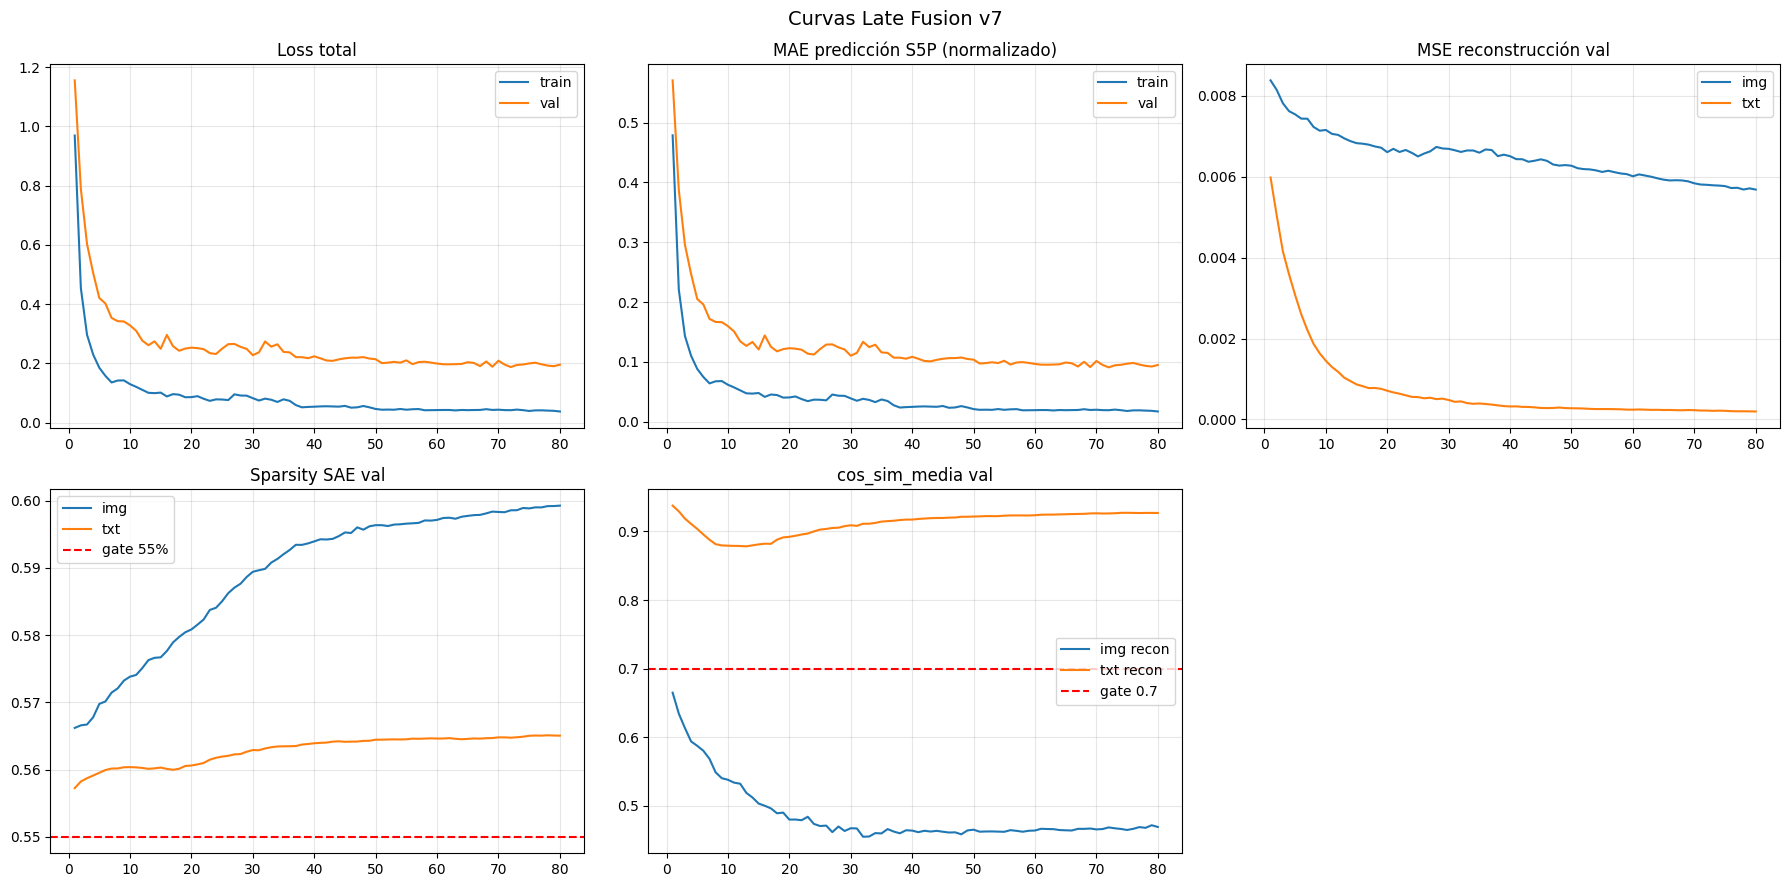

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
ep = history['epoch']

axes[0, 0].plot(ep, history['train_total'], label='train')
axes[0, 0].plot(ep, history['val_total'],   label='val')
axes[0, 0].set_title('Loss total'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep, history['train_mae_pred'], label='train')
axes[0, 1].plot(ep, history['val_mae_pred'],   label='val')
axes[0, 1].set_title('MAE predicción S5P (normalizado)'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(ep, history['val_mse_img'], label='img')
axes[0, 2].plot(ep, history['val_mse_txt'], label='txt')
axes[0, 2].set_title('MSE reconstrucción val'); axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(ep, history['val_sparsity_img'], label='img')
axes[1, 0].plot(ep, history['val_sparsity_txt'], label='txt')
axes[1, 0].axhline(GATE_SPARSITY_MIN, color='r', linestyle='--', label=f'gate {GATE_SPARSITY_MIN:.0%}')
axes[1, 0].set_title('Sparsity SAE val'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep, history['val_cos_sim_img'], label='img recon')
axes[1, 1].plot(ep, history['val_cos_sim_txt'], label='txt recon')
axes[1, 1].axhline(GATE_COS_SIM_MAX, color='r', linestyle='--', label=f'gate {GATE_COS_SIM_MAX}')
axes[1, 1].set_title('cos_sim_media val'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
plt.suptitle('Curvas Late Fusion v7', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curvas_v7.png', dpi=120, bbox_inches='tight')
plt.show()


## 12 - Validación de gates (precondición Fase 2)

In [15]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'late_fusion_best.pt', map_location=device))
model.eval()

# Recalcular métricas finales sobre val (con W_L1 nominal, sin warmup ni reanim)
final = run_epoch(val_loader, train=False, epoch=-1)

# MAE NO2 desnormalizado
@torch.no_grad()
def compute_mae_per_pollutant(loader):
    preds, targs = [], []
    for batch in loader:
        imgs, s5p_vec, tokens, _ = batch
        imgs = imgs.to(device); s5p_vec = s5p_vec.to(device)
        emb_s2  = extract_image_emb_frozen(imgs)
        emb_txt = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out = model(emb_s2, s5p_norm, emb_txt)
        pred = model.gru(out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1))
        preds.append(denormalize_s5p(pred).cpu().numpy())
        targs.append(s5p_vec.cpu().numpy())
    return np.concatenate(preds), np.concatenate(targs)

preds_v, targs_v = compute_mae_per_pollutant(val_loader)
mae_per = np.abs(preds_v - targs_v).mean(axis=0)
std_per = targs_v.std(axis=0) + 1e-8
ratio   = mae_per / std_per

print('MAE val (desnormalizado):')
for i, name in enumerate(['NO2', 'SO2', 'O3']):
    print(f'  {name}: MAE={mae_per[i]:.4e} | std={std_per[i]:.4e} | ratio={ratio[i]:.3f}')

# Gates v8: sparsity con rango [GATE_SPARSITY_MIN, GATE_SPARSITY_MAX] (Ferro Clase 33)
def _in_range(v, lo, hi):
    return lo <= v <= hi

gate_results = {
    'cos_sim_img':   final['cos_sim_img'] < GATE_COS_SIM_MAX,
    'cos_sim_txt':   final['cos_sim_txt'] < GATE_COS_SIM_MAX,
    'sparsity_img':  _in_range(final['sparsity_img'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'sparsity_txt':  _in_range(final['sparsity_txt'], GATE_SPARSITY_MIN, GATE_SPARSITY_MAX),
    'mae_NO2_ratio': ratio[0] < GATE_MAE_NO2_RATIO,
}
print('\nGate Fase 1 -> Fase 2 (parcial, falta skill score):')
for k, v in gate_results.items():
    marca = 'OK' if v else 'FAIL'
    print(f'  [{marca}] {k}')

gate_partial_pass = all(gate_results.values())
print(f'\nGate parcial: {"PASA (esperando skill score)" if gate_partial_pass else "NO PASA"}')

# Guardar métricas parciales; el bloque rolling-origin completa el JSON con el skill score
metricas_v8 = {
    'cos_sim_img':       float(final['cos_sim_img']),
    'cos_sim_txt':       float(final['cos_sim_txt']),
    'sparsity_img':      float(final['sparsity_img']),
    'sparsity_txt':      float(final['sparsity_txt']),
    'mae_NO2':           float(mae_per[0]),
    'mae_SO2':           float(mae_per[1]),
    'mae_O3':            float(mae_per[2]),
    'std_NO2':           float(std_per[0]),
    'std_SO2':           float(std_per[1]),
    'std_O3':            float(std_per[2]),
    'mae_NO2_ratio':     float(ratio[0]),
    'gate_partial_pass': bool(gate_partial_pass),
    'gate_results':      {k: bool(v) for k, v in gate_results.items()},
}


val:   0%|          | 0/5 [00:00<?, ?it/s]

MAE val (desnormalizado):
  NO2: MAE=7.1026e-07 | std=1.4760e-05 | ratio=0.048
  SO2: MAE=3.8199e-05 | std=3.5976e-04 | ratio=0.106
  O3: MAE=4.8252e-04 | std=6.9773e-03 | ratio=0.069

Gate Fase 1 -> Fase 2 (parcial, falta skill score):
  [OK] cos_sim_img
  [FAIL] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio

Gate parcial: NO PASA


## 12b - Rolling-origin validation y persistence baseline

Validación temporal complementaria al gate base. Implementa walk-forward con
`TimeSeriesSplit` sobre el `full_dataset` ordenado por fecha y compara contra un
**persistence baseline** (predecir el valor del día D usando el valor observado
del día D-1 en el mismo tile geográfico). El skill score mayor o igual a 0 indica
que el modelo aporta valor real frente al baseline ingenuo. Patrón tomado de la
literatura de pronóstico de calidad del aire (Sun et al. 2022, IEEE TGRS).

Se ejecuta después de cargar `late_fusion_best.pt` para que el modelo evaluado
sea el de mejor checkpoint, no el del último epoch.


In [16]:
from sklearn.model_selection import TimeSeriesSplit

# Ordenar por fecha para rolling-origin (fechas vacías al final, fuera de folds)
all_dates_sorted_pairs = sorted(
    [(r['date'], i) for i, r in enumerate(full_dataset.records)],
    key=lambda x: (x[0] == '', x[0])
)
all_dates_sorted = [d for d, _ in all_dates_sorted_pairs]
pos_to_global    = {pos: glob_idx
                    for pos, (_, glob_idx) in enumerate(all_dates_sorted_pairs)}


@torch.no_grad()
def rolling_origin_predict(model, full_dataset, val_positions, pos_to_global):
    model.eval()
    preds, targs, idxs_used = [], [], []
    for pos in val_positions:
        global_idx = pos_to_global[pos]
        img_t, s5p_vec, tokens, _meta = full_dataset[global_idx]
        img_t    = img_t.unsqueeze(0).to(device)
        tokens   = tokens.unsqueeze(0).to(device)
        s5p_vec  = s5p_vec.unsqueeze(0).to(device)
        emb_s2   = extract_image_emb_frozen(img_t)
        emb_txt  = extract_text_emb_frozen(tokens)
        s5p_norm = normalize_s5p(s5p_vec)
        out      = model(emb_s2, s5p_norm, emb_txt)
        pred     = model.gru(
            out['emb_fusion'].unsqueeze(1).expand(-1, GRU_WINDOW, -1)
        )
        pred_dn  = denormalize_s5p(pred).cpu().numpy()[0]
        preds.append(pred_dn)
        targs.append(s5p_vec.cpu().numpy()[0])
        idxs_used.append(global_idx)
    return np.array(preds), np.array(targs), idxs_used


def persistence_baseline(full_dataset, idxs_used):
    """
    Baseline: predice el valor del mismo tile en la fecha previa más cercana.
    Si no hay fecha previa, repite el valor actual (cold-start).
    Cambio v8→v9: usa r['lat'] / r['lon'] (esquema normalizado).
    """
    bucket = defaultdict(list)
    for i, r in enumerate(full_dataset.records):
        key = (
            round(float(r.get('lat', 0.0)), 3),
            round(float(r.get('lon', 0.0)), 3),
        )
        bucket[key].append((r.get('date', ''), i))
    for k in bucket:
        bucket[k].sort()

    preds = []
    for idx in idxs_used:
        rec         = full_dataset.records[idx]
        key         = (round(float(rec.get('lat', 0.0)), 3),
                       round(float(rec.get('lon', 0.0)), 3))
        date_actual = rec.get('date', '')
        prev_val    = None
        for d, i_prev in bucket[key]:
            if d < date_actual and i_prev != idx:
                r_prev   = full_dataset.records[i_prev]
                prev_val = [r_prev['val_no2'], r_prev['val_so2'], r_prev['val_o3']]
            elif d >= date_actual:
                break
        if prev_val is None:
            prev_val = [rec['val_no2'], rec['val_so2'], rec['val_o3']]
        preds.append(prev_val)
    return np.array(preds)


n_splits  = 5
positions = np.arange(len(all_dates_sorted))
tscv      = TimeSeriesSplit(n_splits=n_splits, gap=GRU_WINDOW)

mae_model_folds    = []
mae_baseline_folds = []
for fold_id, (_, val_pos) in enumerate(tscv.split(positions)):
    preds_m, targs_m, idxs_used = rolling_origin_predict(
        model, full_dataset, val_pos, pos_to_global
    )
    preds_b   = persistence_baseline(full_dataset, idxs_used)
    mae_m_no2 = float(np.abs(preds_m[:, 0] - targs_m[:, 0]).mean())
    mae_b_no2 = float(np.abs(preds_b[:, 0] - targs_m[:, 0]).mean())
    mae_model_folds.append(mae_m_no2)
    mae_baseline_folds.append(mae_b_no2)
    print(f'  Fold {fold_id+1}: MAE_NO2 modelo={mae_m_no2:.4e} | baseline={mae_b_no2:.4e}')

mae_model_avg    = float(np.mean(mae_model_folds))
mae_baseline_avg = float(np.mean(mae_baseline_folds))
skill_score      = 1.0 - (mae_model_avg / (mae_baseline_avg + 1e-12))

print(f'\nRolling-origin NO2  | modelo avg  : {mae_model_avg:.4e}')
print(f'Rolling-origin NO2  | baseline avg: {mae_baseline_avg:.4e}')
print(f'Skill score (>= {GATE_PERSISTENCE_SKILL_MIN}): {skill_score:.4f}')

gate_skill_pass = skill_score >= GATE_PERSISTENCE_SKILL_MIN
print(f'Gate persistence    : {"OK" if gate_skill_pass else "FAIL"}')


  Fold 1: MAE_NO2 modelo=1.1162e-07 | baseline=1.5578e-05
  Fold 2: MAE_NO2 modelo=1.8167e-07 | baseline=1.6131e-05
  Fold 3: MAE_NO2 modelo=2.0252e-07 | baseline=1.3953e-05
  Fold 4: MAE_NO2 modelo=1.3533e-07 | baseline=1.8542e-05
  Fold 5: MAE_NO2 modelo=6.8363e-07 | baseline=1.8051e-05

Rolling-origin NO2  | modelo avg  : 2.6295e-07
Rolling-origin NO2  | baseline avg: 1.6451e-05
Skill score (>= 0.0): 0.9840
Gate persistence    : OK


## 12c - Gate global Fase 1 -> Fase 2 (cierre v8)

Unifica gates de val, rango sparsity Ferro y skill score rolling-origin.
Persiste `métricas_v8.json` con todos los valores observados, decisión por gate
y la decisión global. Si pasa, la Fase 2 (cokriging) puede consumir el output
sin renegociar criterios.


In [17]:
# Gate global v8: une gates v7 (cos_sim, sparsity_range, mae_NO2) + skill score rolling-origin
metricas_v8['skill_score_NO2']      = float(skill_score)
metricas_v8['mae_rolling_model']    = float(mae_model_avg)
metricas_v8['mae_rolling_baseline'] = float(mae_baseline_avg)
metricas_v8['gate_skill_pass']      = bool(gate_skill_pass)
metricas_v8['gate_results']['skill_score'] = bool(gate_skill_pass)

gate_global_pass = metricas_v8['gate_partial_pass'] and metricas_v8['gate_skill_pass']
metricas_v8['gate_global_pass']     = bool(gate_global_pass)

print('\nResumen gates v8:')
for k, v in metricas_v8['gate_results'].items():
    marca = 'OK' if v else 'FAIL'
    print(f'  [{marca}] {k}')
print(f'\nGate global v8: {"PASA - listo para Fase 2 (cokriging)" if gate_global_pass else "NO PASA - iterar D antes de tocar Fase 2"}')

# Persistir métricas_v8.json
import json as _json
metrics_path = OUTPUT_DIR / 'metricas_v8.json'
with open(metrics_path, 'w', encoding='utf-8') as _f:
    _json.dump(metricas_v8, _f, ensure_ascii=False, indent=2)
print(f'\nMétricas guardadas en: {metrics_path}')



Resumen gates v8:
  [OK] cos_sim_img
  [FAIL] cos_sim_txt
  [OK] sparsity_img
  [OK] sparsity_txt
  [OK] mae_NO2_ratio
  [OK] skill_score

Gate global v8: NO PASA - iterar D antes de tocar Fase 2

Métricas guardadas en: D:\analitica\outputs_geovision\v8_latefusion\metricas_v8.json


## 13 - Generar predicciones GRU sobre dataset completo (input Fase 2)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Predicción robusta FULL DATASET
# Correcciones:
#   1. safe_collate anti-None.
#   2. Protección batch corrupto.
#   3. Protección embeddings corruptos.
#   4. Protección forward corrupto.
#   5. Compatibilidad metadata segura.
#   6. Persistencia robusta parquet.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
from tqdm.auto import tqdm

from torch.utils.data import DataLoader


# ─────────────────────────────────────────────────────────────────────────────
# DataLoader robusto
# ─────────────────────────────────────────────────────────────────────────────

full_loader_seq = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=safe_collate
)


# ─────────────────────────────────────────────────────────────────────────────
# Predicción
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def predict_full(full_loader):

    model.eval()

    preds_records = []

    for batch_idx, batch in enumerate(
        tqdm(full_loader, desc='predict full')
    ):

        # ───────────────────────────────────────────────────────────────────
        # unpack
        # ───────────────────────────────────────────────────────────────────

        try:

            imgs, s5p_vec, tokens, meta = batch

        except Exception as e:

            print(
                f'[warn] batch corrupto '
                f'idx={batch_idx}: {e}'
            )

            continue

        # ───────────────────────────────────────────────────────────────────
        # device
        # ───────────────────────────────────────────────────────────────────

        try:

            imgs = imgs.to(device)

            s5p_vec = s5p_vec.to(device)

            if torch.is_tensor(tokens):

                tokens = tokens.to(device)

        except Exception as e:

            print(
                f'[warn] fallo device '
                f'batch={batch_idx}: {e}'
            )

            continue

        # ───────────────────────────────────────────────────────────────────
        # embeddings
        # ───────────────────────────────────────────────────────────────────

        try:

            emb_s2 = extract_image_emb_frozen(imgs)

            emb_txt = extract_text_emb_frozen(tokens)

            s5p_norm = normalize_s5p(s5p_vec)

        except Exception as e:

            print(
                f'[warn] embeddings fallo '
                f'batch={batch_idx}: {e}'
            )

            continue

        # ───────────────────────────────────────────────────────────────────
        # forward
        # ───────────────────────────────────────────────────────────────────

        try:

            out = model(
                emb_s2,
                s5p_norm,
                emb_txt
            )

            pred_n = model.gru(

                out['emb_fusion']
                .unsqueeze(1)
                .expand(-1, GRU_WINDOW, -1)

            )

            pred = denormalize_s5p(
                pred_n
            ).cpu().numpy()

        except Exception as e:

            print(
                f'[warn] forward fallo '
                f'batch={batch_idx}: {e}'
            )

            continue

        # ───────────────────────────────────────────────────────────────────
        # guardar predicciones
        # ───────────────────────────────────────────────────────────────────

        B = imgs.shape[0]

        for b in range(B):

            try:

                preds_records.append({

                    'pair_id': (
                        meta['pair_id'][b]
                        if 'pair_id' in meta
                        else ''
                    ),

                    'tile_id': int(
                        meta['tile_id'][b]
                    ),

                    'fecha': (
                        meta['date'][b]
                        if 'date' in meta
                        else ''
                    ),

                    'lat': float(
                        meta['lat'][b]
                    ),

                    'lon': float(
                        meta['lon'][b]
                    ),

                    'P_NO2': float(
                        pred[b, 0]
                    ),

                    'P_SO2': float(
                        pred[b, 1]
                    ),

                    'P_O3': float(
                        pred[b, 2]
                    ),
                })

            except Exception as e:

                print(
                    f'[warn] fallo guardando sample '
                    f'batch={batch_idx} sample={b}: {e}'
                )

                continue

    return preds_records


# ─────────────────────────────────────────────────────────────────────────────
# Ejecutar predicción
# ─────────────────────────────────────────────────────────────────────────────

pred_records = predict_full(
    full_loader_seq
)

print(
    f'Predicciones generadas: '
    f'{len(pred_records):,}'
)


# ─────────────────────────────────────────────────────────────────────────────
# DataFrame
# ─────────────────────────────────────────────────────────────────────────────

df_pred = pd.DataFrame(pred_records)

print(df_pred.head())


# ─────────────────────────────────────────────────────────────────────────────
# Persistencia parquet
# ─────────────────────────────────────────────────────────────────────────────

OUT_PRED = OUTPUT_DIR / 'predicciones_gru.parquet'

try:

    df_pred.to_parquet(
        OUT_PRED,
        index=False
    )

    print(
        f'Persistido correctamente: '
        f'{OUT_PRED}'
    )

except Exception as e:

    print(
        f'[warn] fallo guardando parquet: {e}'
    )

    # fallback CSV
    OUT_CSV = OUTPUT_DIR / 'predicciones_gru.csv'

    df_pred.to_csv(
        OUT_CSV,
        index=False
    )

    print(
        f'Fallback CSV persistido: '
        f'{OUT_CSV}'
    )

predict full:   0%|          | 0/31 [00:00<?, ?it/s]

Predicciones generadas: 990
                                  pair_id  tile_id       fecha       lat  \
0  high_NO2_pollution_2022-06-05_181_0000      181  2022-06-05  3.121543   
1   high_NO2_pollution_2020-07-30_55_0001       55  2020-07-30  3.121543   
2  high_NO2_pollution_2023-11-27_235_0002      235  2023-11-27  3.121543   
3  high_NO2_pollution_2023-02-10_202_0003      202  2023-02-10  3.121543   
4   high_NO2_pollution_2020-10-23_77_0004       77  2020-10-23  3.121543   

         lon     P_NO2     P_SO2      P_O3  
0 -76.305557  0.000024  0.000047  0.116557  
1 -76.305557  0.000028  0.000002  0.119830  
2 -76.305557  0.000023 -0.000107  0.115219  
3 -76.305557  0.000021 -0.000069  0.114785  
4 -76.305557  0.000023  0.000005  0.117455  
Persistido correctamente: D:\analitica\outputs_geovision\v8_latefusion\predicciones_gru.parquet


que pasho?,dio 

## 14 - Trazabilidad MD5 de artefactos

In [20]:
def md5_file(path: Path) -> str:
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


artefactos = [
    OUTPUT_DIR / 'late_fusion_best.pt',
    OUTPUT_DIR / 'curvas_v8.png',
    OUTPUT_DIR / 'predicciones_gru.parquet',
]

trazabilidad = {}
for p in artefactos:
    if p.exists():
        trazabilidad[p.name] = {'md5': md5_file(p), 'size_bytes': p.stat().st_size}
        print(f'{p.name}: md5={trazabilidad[p.name]["md5"]} size={trazabilidad[p.name]["size_bytes"]:,} B')

trazabilidad['gate_results']     = metricas_v8['gate_results']
trazabilidad['gate_global_pass'] = metricas_v8['gate_global_pass']
trazabilidad['mae_per_pollutant'] = {
    name: {'mae': float(mae_per[i]), 'std': float(std_per[i]), 'ratio': float(ratio[i])}
    for i, name in enumerate(['NO2', 'SO2', 'O3'])
}
trazabilidad['final_metrics']    = {k: float(v) for k, v in final.items()}
trazabilidad['rolling_origin']   = {
    'skill_score_NO2':      float(skill_score),
    'mae_rolling_model':    float(mae_model_avg),
    'mae_rolling_baseline': float(mae_baseline_avg),
}
trazabilidad['hiperparams'] = {
    'SEED': SEED, 'EXPANSION_FACTOR': EXPANSION_FACTOR, 'EXPANSION_DIM': EXPANSION_DIM,
    'BATCH_SIZE': BATCH_SIZE, 'LR': LR, 'WD': WD, 'GRU_WINDOW': GRU_WINDOW,
    'GRU_HIDDEN': GRU_HIDDEN, 'GRU_LAYERS': GRU_LAYERS,
    'W_RECON_IMG': W_RECON_IMG, 'W_RECON_TXT': W_RECON_TXT,
    'W_L1_IMG': W_L1_IMG, 'W_L1_TXT': W_L1_TXT, 'W_PRED': W_PRED,
    'L1_WARMUP_EPOCHS': L1_WARMUP_EPOCHS, 'REANIM_COEF': REANIM_COEF,
    'USE_TIME_SPLIT': USE_TIME_SPLIT, 'TIME_SPLIT_RATIO': TIME_SPLIT_RATIO,
    'TIME_SPLIT_GAP_DAYS': TIME_SPLIT_GAP_DAYS,
    'GATE_SPARSITY_MIN': GATE_SPARSITY_MIN, 'GATE_SPARSITY_MAX': GATE_SPARSITY_MAX,
    'GATE_PERSISTENCE_SKILL_MIN': GATE_PERSISTENCE_SKILL_MIN,
}

# Mezclar trazabilidad sobre el JSON ya guardado por la cell 12c
import json as _json
metrics_path = OUTPUT_DIR / 'metricas_v8.json'
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as _f:
        existing = _json.load(_f)
    existing['trazabilidad'] = trazabilidad
    with open(metrics_path, 'w', encoding='utf-8') as _f:
        _json.dump(existing, _f, ensure_ascii=False, indent=2)
else:
    with open(metrics_path, 'w', encoding='utf-8') as _f:
        _json.dump({'trazabilidad': trazabilidad}, _f, ensure_ascii=False, indent=2)
print(f'\nTrazabilidad guardada en: {metrics_path}')


late_fusion_best.pt: md5=db3bc5004d173ea2bbbe245e02829af0 size=72,693,342 B
predicciones_gru.parquet: md5=ceb085972fa7aa860a70f8a95158f0c5 size=39,986 B

Trazabilidad guardada en: D:\analitica\outputs_geovision\v8_latefusion\metricas_v8.json


## 15 — Próximos pasos

1. Revisar `metricas_v8.json` y confirmar `gate_global_pass`.
   - Si es `True` → abrir **`04_Kriging_Funcional.ipynb`** (Fase 2).  
     El parquet `predicciones_gru.parquet` con columnas `(lat, lon, fecha, P_NO2, P_SO2, P_O3)`
     es el input directo del **Kriging Funcional** sobre la grilla de Cali.
   - Si es `False` → iterar sobre Late Fusion v8:
     - `cos_sim_txt` no baja: ampliar `MAGNITUDE_LEVELS`, `SEASONS_CALI` o `URBAN_CONTEXTS`.
     - `sparsity` fuera del rango Ferro [0.55, 0.65]: ajustar `W_L1_IMG` / `W_L1_TXT`.
     - `mae_NO2_ratio` alto bajo split temporal: confirmar que v7 era leaky y reportarlo.
     - `skill_score_NO2` negativo: GRU no supera persistencia → subir `GRU_WINDOW` a 14.

2. El parquet `predicciones_gru.parquet` alimenta el **Kriging Funcional**
   (aprobado por el profe en reemplazo del CoKriging Universal) con
   `(lat, lon, fecha, P_NO2, P_SO2, P_O3)` como pseudo-observaciones.
   La varianza de predicción σ²(s,t) del Kriging se usa para el mapa de incertidumbre.

3. Si `fuente_centroide == 'sam_segment'` domina el dataset
   (el notebook 02b corrió antes del 02 v11), analizar si los segmentos SAM
   mejoran la separación de clases en el espacio latente del SAE.
   Ver `embeddings_fusion.npy` para la visualización UMAP/t-SNE post-train.

4. Interpretabilidad SAE: qué neuronas de `SAE_img` se activan por clase
   (`contaminacion_alta_NO2`, `dense_vegetation`, etc.) comparando `z_img`
   por clase en el set de validación.

5. Persistir en `agent-docs/handoffs/<fecha>/<fecha>-resultados-v8.md` qué gates
   pasaron y cuáles no, para la siguiente ronda si el gate global no cierra.
